## Решающие деревья

### О задании

Задание состоит из двух разделов:
1. В первом разделе вы научитесь применять деревья из sklearn для задачи классификации. Вы посмотрите какие разделяющие поверхности деревья строят для различных датасетов и проанализируете их зависимость от различных гиперпараметров.
2. Во втором разделе вы попробуете реализовать свое решающее дерево и сравните его со стандартное имплиментацией из sklearn. Вы также протестируете деревья на более сложных датасетах и сравните различные подходы к кодированию категориальных признаков.

### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.


### Формат сдачи
Решение должно содержать:
* Ноутбук homework-practice-05-Username.ipynb
* Модуль hw5code.py

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__ я насчитал 5.5 баллов

In [ ]:
import numpy as np
from collections import Counter
from sklearn.base import BaseEstimator, ClassifierMixin

class DecisionTree(BaseEstimator):#, ClassifierMixin):
    def __init__(self, feature_types):#, max_depth=None, min_samples_split=None, min_samples_leaf=None):
        self.feature_types = feature_types
#         if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
#             raise ValueError("There is unknown feature type")

    def fit(self, X, y):
        self._fit_node(X, y, self._tree)

    def predict(self, X):
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))
        return np.array(predicted)

clf = DecisionTree(feature_types=['real'] * 5)
clf

DecisionTree(feature_types=['real', 'real', 'real', 'real', 'real'])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from matplotlib.colors import Colormap, ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# 1. Решающие деревья. Визуализация.

В этой части мы рассмотрим два простых двумерных датасета сделанных с помощью `make_moons`, `make_circles` и посмотрим как ведет себя разделяющая поверхность в зависимости от различных гиперпараметров.

In [ ]:
from sklearn.datasets import make_moons, make_circles, make_classification
datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42) #,
    # make_classification(n_classes=3, n_clusters_per_class=1, n_features=2, class_sep=.8, random_state=3,
    #                     n_redundant=0., )
]

In [ ]:
palette = sns.color_palette(n_colors=3)
cmap = ListedColormap(palette)

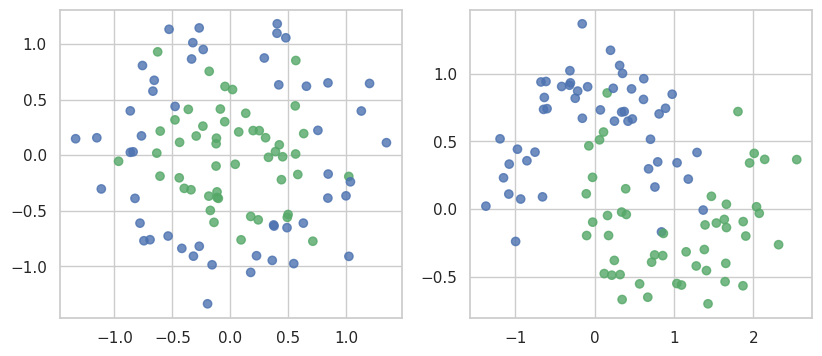

In [ ]:
plt.figure(figsize=(15, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap=cmap, alpha=.8)

__1. (1 балл)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности (для этого воспользуйтесь функцией `plot_surface`, пример ниже). Посчитайте accuracy на обучающей и тестовой выборках. Сильно ли деревья переобучились?

In [ ]:


def plot_surface(clf, X, y):
    plot_step = 0.01
    palette = sns.color_palette(n_colors=len(np.unique(y)))
    cmap = ListedColormap(palette)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, alpha=.7,
                edgecolors=np.array(palette)[y], linewidths=2)

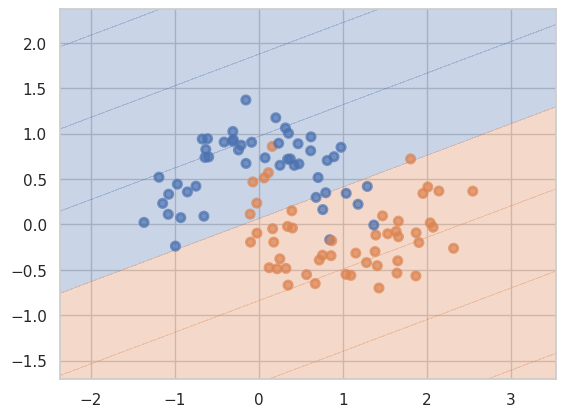

In [ ]:
# Пример:
from sklearn.linear_model import LinearRegression
X, y = datasets[1]
lr  = LinearRegression().fit(X, y)
plot_surface(lr, X, y)

Доля ошибок на тестовой выборке:  0.1
доля верных ответов на обучающей выборке :  1.0


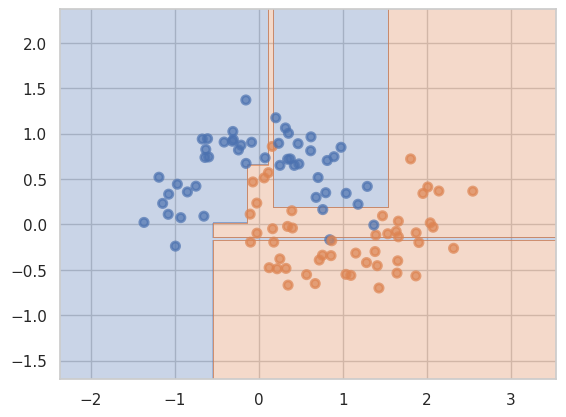

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
from sklearn.tree import DecisionTreeClassifier

X, y = datasets[1]
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

dtc  = DecisionTreeClassifier().fit(X_train, y_train)
plot_surface(dtc, X, y)

print("Доля ошибок на тестовой выборке: ", np.sum(dtc.predict(X_test) - y_test)/len(y_test))
print("доля верных ответов на обучающей выборке : ", np.sum(dtc.predict(X_train) == y_train)/len(y_train))



__Ответ:__ модель явно переобучилась

__2. (1.5 балла)__

Попробуйте перебрать несколько параметров для регуляризации (напр. `max_depth`, `min_samples_leaf`). Для каждого набора гиперпараметров постройте разделяющую поверхность, выведите обучающую и тестовую ошибки. Можно делать кросс-валидацию или просто разбиение на трейн и тест, главное делайте каждый раз одинаковое разбиение, чтобы можно было корректно сравнивать (помните же, что итоговое дерево сильно зависит от небольшого изменения обучающей выборки?). Проследите как меняется разделяющая поверхность и обобщающая способность. Почему так происходит, одинаково ли изменение для разных датасетов?

Процент верных ответов на тестовой выборке 1:  80.0
Процент верных ответов на обучающей выборке 1:  92.5
Процент верных ответов на тестовой выборке 2:  85.0
Процент верных ответов на обучающей выборке 2:  95.0
Процент верных ответов  на тестовой выборке 3:  80.0
Процент верных ответов на обучающей выборке 3:  91.25


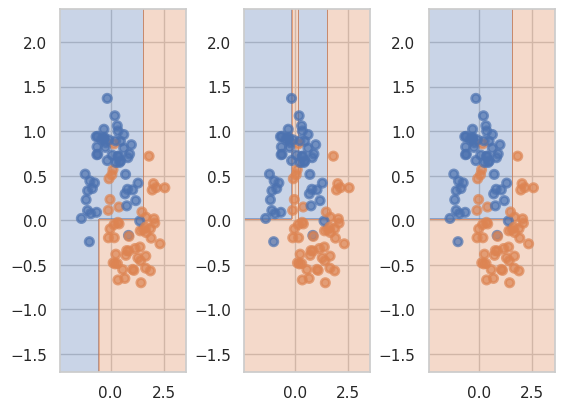

In [54]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ     датасет номер два           ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

from sklearn.tree import DecisionTreeClassifier

X, y = datasets[1]
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

plt.subplot(1, 3, 1)
dtc  = DecisionTreeClassifier(max_depth=3).fit(X_train, y_train)
plot_surface(dtc, X, y)
print("Процент верных ответов на тестовой выборке 1: ", 100*np.sum(dtc.predict(X_test) == y_test)/len(y_test))
print("Процент верных ответов на обучающей выборке 1: ", 100*np.sum(dtc.predict(X_train) == y_train)/len(y_train))

plt.subplot(1, 3, 2)
dtc  = DecisionTreeClassifier(min_samples_leaf=3).fit(X_train, y_train)
plot_surface(dtc, X, y)
print("Процент верных ответов на тестовой выборке 2: ", 100*np.sum(dtc.predict(X_test) == y_test)/len(y_test))
print("Процент верных ответов на обучающей выборке 2: ", 100*np.sum(dtc.predict(X_train) == y_train)/len(y_train))

plt.subplot(1, 3, 3)
dtc  = DecisionTreeClassifier(max_depth=3, min_samples_leaf=3).fit(X_train, y_train)
plot_surface(dtc, X, y)
print("Процент верных ответов  на тестовой выборке 3: ", 100*np.sum(dtc.predict(X_test) == y_test)/len(y_test))
print("Процент верных ответов на обучающей выборке 3: ", 100*np.sum(dtc.predict(X_train) == y_train)/len(y_train))

Процент верных ответов на тестовой выборке 1:  85.0
Процент верных ответов на обучающей выборке 1:  87.5
Процент верных ответов на тестовой выборке 2:  85.0
Процент верных ответов на обучающей выборке 2:  93.75
Процент верных ответов  на тестовой выборке 3:  80.0
Процент верных ответов на обучающей выборке 3:  87.5


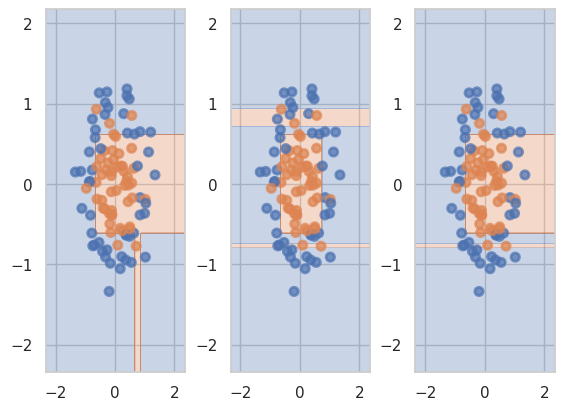

In [55]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ     датасет номер один           ### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ

from sklearn.tree import DecisionTreeClassifier

X, y = datasets[0]
X_train = X[:80]
y_train = y[:80]
X_test = X[80:]
y_test = y[80:]

plt.subplot(1, 3, 1)
dtc  = DecisionTreeClassifier(max_depth=3).fit(X_train, y_train)
plot_surface(dtc, X, y)
print("Процент верных ответов на тестовой выборке 1: ", 100*np.sum(dtc.predict(X_test) == y_test)/len(y_test))
print("Процент верных ответов на обучающей выборке 1: ", 100*np.sum(dtc.predict(X_train) == y_train)/len(y_train))

plt.subplot(1, 3, 2)
dtc  = DecisionTreeClassifier(min_samples_leaf=3).fit(X_train, y_train)
plot_surface(dtc, X, y)
print("Процент верных ответов на тестовой выборке 2: ", 100*np.sum(dtc.predict(X_test) == y_test)/len(y_test))
print("Процент верных ответов на обучающей выборке 2: ", 100*np.sum(dtc.predict(X_train) == y_train)/len(y_train))

plt.subplot(1, 3, 3)
dtc  = DecisionTreeClassifier(max_depth=3, min_samples_leaf=3).fit(X_train, y_train)
plot_surface(dtc, X, y)
print("Процент верных ответов  на тестовой выборке 3: ", 100*np.sum(dtc.predict(X_test) == y_test)/len(y_test))
print("Процент верных ответов на обучающей выборке 3: ", 100*np.sum(dtc.predict(X_train) == y_train)/len(y_train))

__Ответ:__ данные регуляризующие параметры повышают способность модели обобщать. На обоих датасетах именно ограничение параметра минимального количества объектов на лист позволило разделяющей поверхности уловить струткуру данных. Накладывание обоих ограничений сразу делает модель слишком слабо обучаемой

# 2. Решающие деревья своими руками

В этой части вам нужно реализовать свой класс для обучения решающего дерева в задаче бинарной классификации с возможностью обработки вещественных и категориальных признаков.

__3. (1.5 балл)__

Реализуйте функцию find_best_split из модуля hw5code.py

__4. (0.5 балла)__

Загрузите таблицу [students.csv](https://drive.google.com/file/d/0B2zoFVYw1rN3a0d0Zm43TzQ4aUU/view?usp=sharing) (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте scatter-графики "значение признака — класс" для всех пяти признаков.

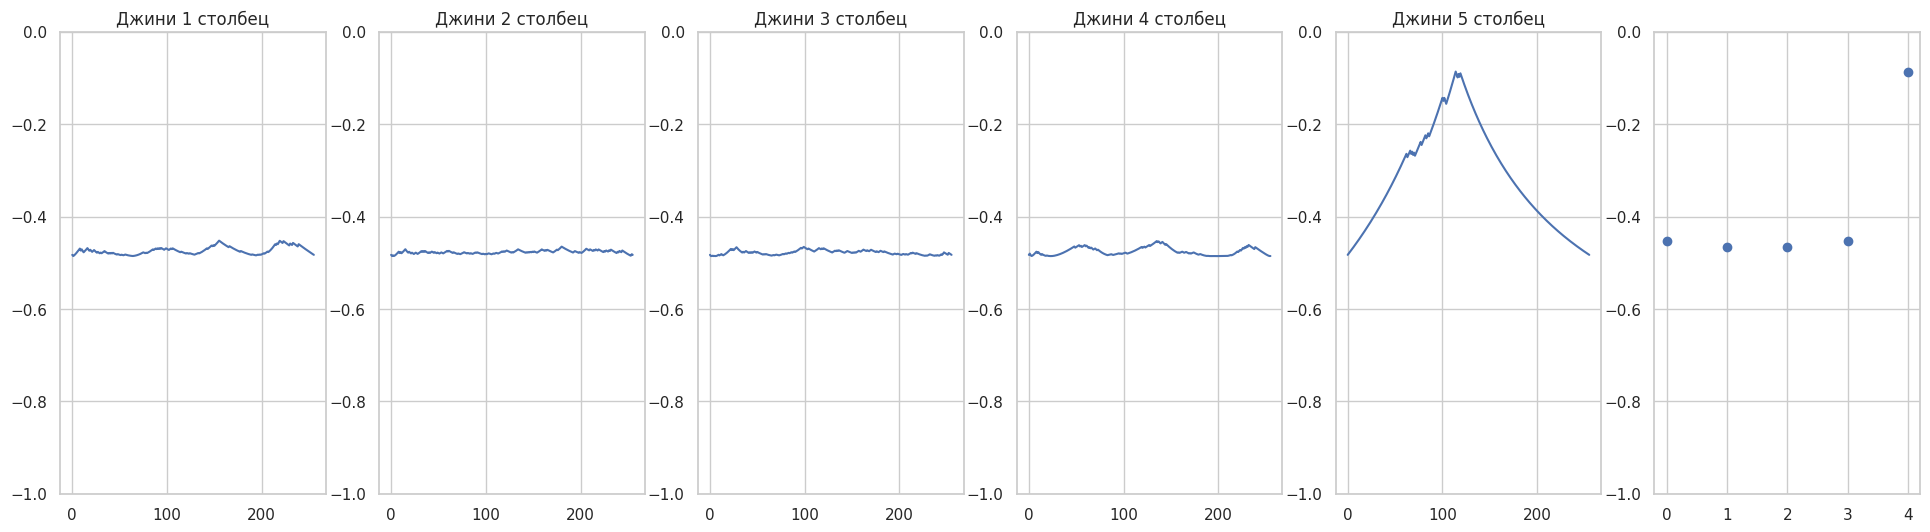

In [56]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ


import numpy as np
from collections import Counter
from sklearn.base import BaseEstimator

def _prep_table_(feature_vector, target_vector, target):
    a = np.c_[feature_vector, target_vector.T]
    return a[a[:, target].argsort()]

def _prep_column_(feature_vector, target_vector):
    a = np.c_[feature_vector.T, target_vector.T]
    return a[a[:, 0].argsort()]

def H(y_r):
    s = np.sum(y_r)
    return 1 - (s / len(y_r))**2 - ((len(y_r) - s)/ len(y_r))**2

def Q(D, i):
    D_1 = np.array(D[:i])
    D_2 = np.array(D[i:])
    return -1 * len(D_1) * H(D_1[:, 1]) / len(D) - len(D_2) * H(D_2[:, 1]) / len(D)

def find_best_split(feature_vector, target_vector):
    """
    Под критерием Джини здесь подразумевается следующая функция:
    $$Q(R) = -\frac {|R_l|}{|R|}H(R_l) -\frac {|R_r|}{|R|}H(R_r)$$,
    $R$ — множество объектов, $R_l$ и $R_r$ — объекты, попавшие в левое и правое поддерево,
     $H(R) = 1-p_1^2-p_0^2$, $p_1$, $p_0$ — доля объектов класса 1 и 0 соответственно.

    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)

    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """
    #

    D = _prep_column_(feature_vector, target_vector)

    Q_max = -10
    poz = 1
    Q_mass = []

    for i in range(1, len(D)-1):
        Q_temp = Q(D, i)
        Q_mass.append(Q_temp)
        if (Q_temp > Q_max):
            Q_max = Q_temp
            poz = i

    Z = np.zeros((len(D[:, 0])-1, len(D[:, ])))
    for i in range(0, len(Z)):
        Z[i, i], Z[i, i+1] = 0.5, 0.5

    thresholds = Z @ D[:, 0]

    gini_best = np.max(thresholds)


    return thresholds, np.array(Q_mass), gini_best, Q_max


### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ
import pandas as pd

DATA = pd.read_excel('students.xls', sheet_name="Training_Data")

D = DATA.to_numpy()
X, y = D[:, :-1], D[:, -1]

Q_mass = []

for i in X.T:
    Q_mass.append(find_best_split(i, y)[-1])

plt.figure(figsize=(24, 6))
for i, x in zip(range(len(X[0])), X.T):
    plt.subplot(1, 6, i + 1)
    _, mass, _, _, = find_best_split(x, y)
    plt.ylim(-1, 0)
    plt.plot(mass)
    plt.title("Джини {} столбец".format(i+1))

plt.subplot(1, 6, 6)
plt.ylim(-1, 0)
plt.scatter(range(0, 5), Q_mass)


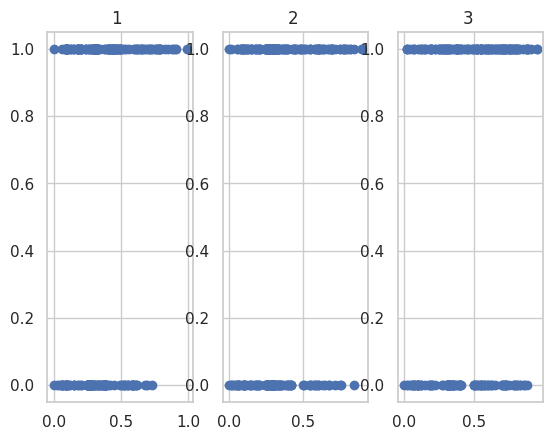

In [62]:
#скатерти
for i, x in zip(range(len(X[0])-2), X.T):
    plt.subplot(1, 3, i + 1)
    plt.scatter(X.T[i], y)
    plt.title("{} ".format(i+1))


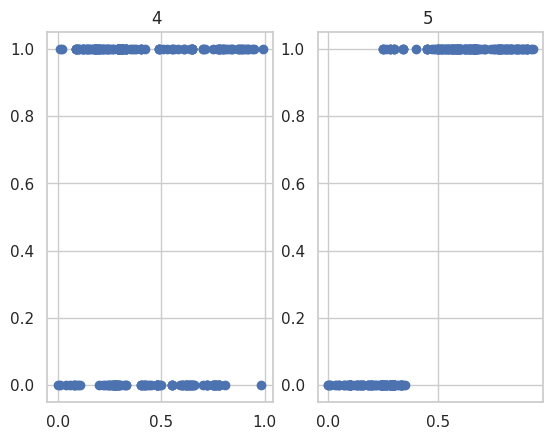

In [67]:
for i, x in zip(range(3, len(X[0])), X.T):
    plt.subplot(1, 2, i -2)

    plt.scatter(X.T[i], y)
    plt.title("{} ".format(i+1))

__5. (0.5 балла)__

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой scatter-графиков? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

**Ответ:** исходя из кривых значения Джини нужно проводить деление выборки по пятому признаку, что полностью согласуется с оценкой графиков - на графике по пятому признаку явно заметно разбиение выборки на два класса по этому параметру в районе 1/6. Кривая для хороших признаков должна иметь вид горки. плохие признаки не имеют высоких пиков

__6. (1.5 балла).__

Разберитесь с уже написанным кодом в классе DecisionTree модуля hw5code.py. Найдите ошибки в реализации метода \_fit_node. Напишите функцию \_predict_node.

 Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2016-fall/lecture-notes/lecture07-trees.pdf) в разделе «Построение дерева». Выбор лучшего разбиения необходимо производить по критерию Джини. Критерий останова: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку. Ответ в листе: наиболее часто встречающийся класс в листе. Для категориальных признаков выполняется преобразование, описанное в лекции в разделе «Учет категориальных признаков».

__7. (0.5 балла)__

Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Вам нужно скачать таблицу agaricus-lepiota.data (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)), прочитать ее с помощью pandas, применить к каждому столбцу LabelEncoder (из sklearn), чтобы преобразовать строковые имена категорий в натуральные числа. Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

У вас должно получиться значение accuracy, равное единице (или очень близкое к единице), и не очень глубокое дерево.

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ


__14. (бонус, 1 балл)__

Реализуйте в классе DecisionTree поддержку параметров max_depth, min_samples_split и min_samples_leaf по аналогии с DecisionTreeClassifier. Постройте графики зависимости качества предсказания в зависимости от этих параметров для набора данных tic-tac-toe (см. следующий пункт).

__15. (2 балла)__

Загрузите следующие наборы данных (напомним, что pandas умеет загружать файлы по url, в нашем случае это файл \*.data), предварительно ознакомившись с описанием признаков и целевой переменной в каждом из них (она записаны в Data Folder, в файле *.names):
* [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom) (загрузили в предыдущем пункте, классы записаны в нулевом столбце),
* [tic-tac-toe](https://archive.ics.uci.edu/ml/datasets/Tic-Tac-Toe+Endgame) (классы записаны в последнем столбце)
* [cars](https://archive.ics.uci.edu/ml/datasets/Car+Evaluation) (классы записаны в последнем столбце, считаем что unacc, acc — это класс 0, good, vgood — класс 1)
* [nursery](https://archive.ics.uci.edu/ml/datasets/Nursery) (классы записаны в последнем столбце, считаем, что not_recom и recommend — класс 0, very_recom, priority, spec_prior — класс 1).

Закодируйте категориальные признаки, использовав LabelEncoder. С помощью cross_val_score (cv=10) оцените accuracy на каждом из этих наборов данных следующих алгоритмов:
* DecisionTree, считающий все признаки вещественными
* DecisionTree, считающий все признаки категориальными
* DecisionTree, считающий все признаки вещественными + one-hot-encoding всех признаков
* DecisionTreeClassifier из sklearn. Запишите результат в pd.DataFrame (по строкам — наборы данных, по столбцам — алгоритмы).

Рекомендации:
* Чтобы cross_val_score вычисляла точность, нужно передать scoring=make_scorer(accuracy_score), обе фукнции из sklearn.metrics.
* Если вам позволяет память (а она скорее всего позволяет), указывайте параметр sparse=False в OneHotEncoder (если вы, конечно, используете его). Иначе вам придется добиваться того, чтобы ваша реализация дерева умела работать с разреженными матрицами (что тоже, в целом, не очень сложно).

In [ ]:
### ╰( ͡° ͜ʖ ͡° )つ──☆*:・ﾟ


__16. (1 балла)__

Проанализируйте результаты эксперимента.
Одинаково ли для разных наборов данных ранжируются алгоритмы?
Порассуждайте, почему так происходит.

Обратите внимание на значение признаков в разных наборах данных.
Присутствует ли в результатах какая-то компонента случайности?
Можно ли повлиять на нее и улушить работу алгоритмов?

**Ответ:**